In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [ ]:
#Unzip the dataset
import zipfile
import os

# Target the zip file present in the directory
target_zip = 'archive.zip'

if os.path.exists(target_zip):
    print(f"Unzipping: {target_zip}")
    with zipfile.ZipFile(target_zip, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Done!")
else:
    print(f"Error: {target_zip} not found. Please ensure the file is uploaded.")
    print("Files in directory:", os.listdir('.'))

Unzipping: archive.zip
Done!


In [ ]:
#Confirm the folder structure and current directory
import os
print("Current Directory:", os.getcwd())
print("Files in directory:", os.listdir())

Current Directory: /content
Files in directory: ['.config', 'archive.zip', 'Brain (y-n)', '.ipynb_checkpoints', 'sample_data']


In [ ]:
import os

data_dir = "Brain (y-n)/Training"
yes_path = os.path.join(data_dir, "yes")
no_path  = os.path.join(data_dir, "no")

# Check if the directories exist before trying to list them
if os.path.exists(yes_path) and os.path.exists(no_path):
    num_yes = len(os.listdir(yes_path))
    num_no  = len(os.listdir(no_path))

    print("Number of YES images:", num_yes)
    print("Number of NO images :", num_no)
    print("Total images        :", num_yes + num_no)
else:
    print(f"Error: Directory not found at {data_dir}")
    print("Please ensure your dataset has been uploaded and unzipped correctly.")
    print("Current files in directory:", os.listdir('.'))

Number of YES images: 2725
Number of NO images : 2725
Total images        : 5450


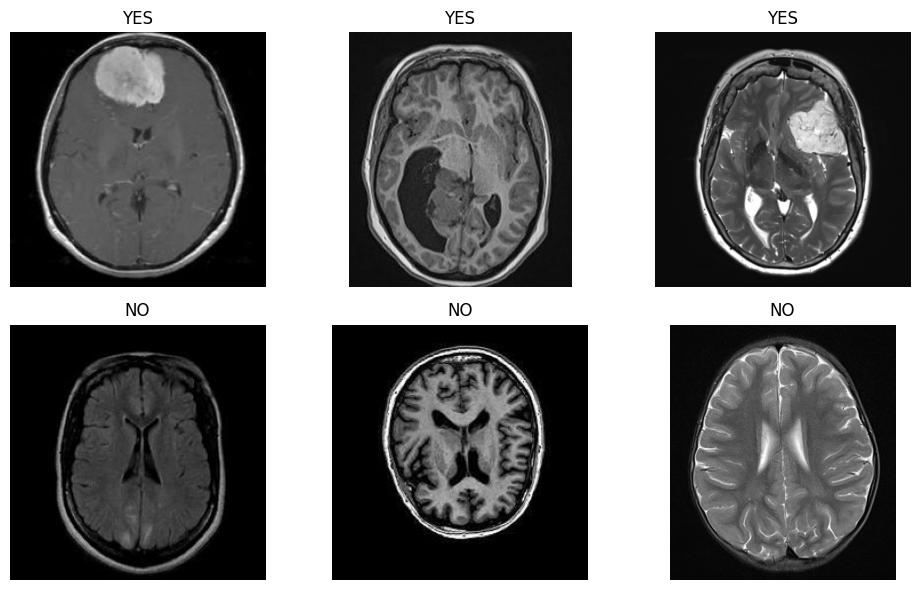

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10, 6))

# Show 3 YES images
for i, img_name in enumerate(os.listdir(yes_path)[:3]):
    img = Image.open(os.path.join(yes_path, img_name))
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap="gray")
    plt.title("YES")
    plt.axis("off")

# Show 3 NO images
for i, img_name in enumerate(os.listdir(no_path)[:3]):
    img = Image.open(os.path.join(no_path, img_name))
    plt.subplot(2, 3, i+4)
    plt.imshow(img, cmap="gray")
    plt.title("NO")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
#Create train & validation datasets with TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models


img_size = (128, 128)
batch_size = 16

data_dir = "Brain (y-n)/Training"   # root folder with 'no' and 'yes'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,     # 80% train, 20% val
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


Found 5450 files belonging to 2 classes.
Using 4360 files for training.
Found 5450 files belonging to 2 classes.
Using 1090 files for validation.
Classes: ['no', 'yes']


In [ ]:
#Check how many batches & one example batch
train_batches = tf.data.experimental.cardinality(train_ds)
val_batches = tf.data.experimental.cardinality(val_ds)

print("Train batches:", train_batches.numpy())
print("Val batches  :", val_batches.numpy())

for images, labels in train_ds.take(1):
    print("One train batch shape:", images.shape)
    print("One train batch labels:", labels.numpy())


Train batches: 273
Val batches  : 69
One train batch shape: (16, 128, 128, 3)
One train batch labels: [1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 0]


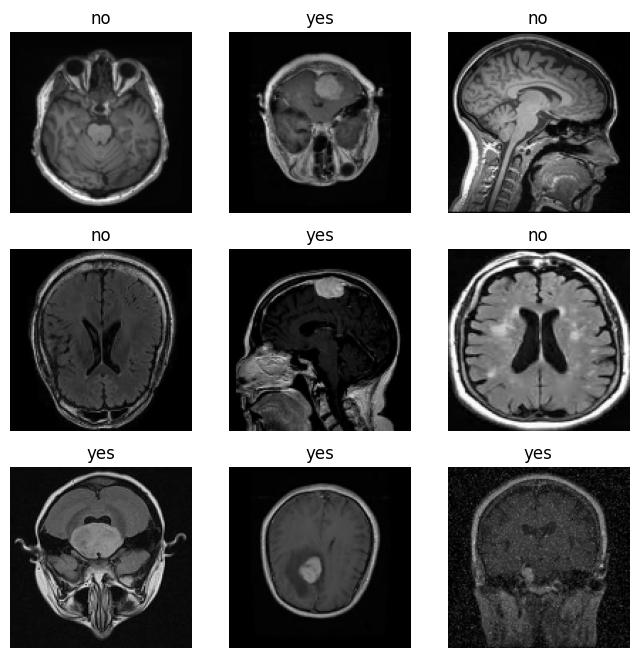

In [ ]:
#Visualise a few training images from the tf dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [ ]:
#Traditional CNN (no transfer learning)
from tensorflow.keras import layers, models

img_size = (128, 128)

inputs = layers.Input(shape=img_size + (3,))

x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)  # 0 = no, 1 = yes

model_scratch = models.Model(inputs, outputs)

model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_scratch.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train traditional CNN
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,       # you can change to 5–12
    verbose=1
)

val_loss_s, val_acc_s = model_scratch.evaluate(val_ds, verbose=0)
print("Baseline CNN - Val accuracy:", val_acc_s)


Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.5154 - loss: 0.6903 - val_accuracy: 0.5110 - val_loss: 0.6842
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5706 - loss: 0.6812 - val_accuracy: 0.6275 - val_loss: 0.6632
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6007 - loss: 0.6675 - val_accuracy: 0.6339 - val_loss: 0.6478
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6133 - loss: 0.6588 - val_accuracy: 0.6486 - val_loss: 0.6384
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6211 - loss: 0.6536 - val_accuracy: 0.6523 - val_loss: 0.6317
Baseline CNN - Val accuracy: 0.6522935628890991


In [ ]:
#Confusion matrix: traditional CNN
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    probs = model_scratch.predict(images)
    preds = (probs >= 0.5).astype("int32").reshape(-1)  # 0 or 1

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm_scratch = confusion_matrix(y_true, y_pred)
print("Confusion matrix (CNN from scratch):")
print(cm_scratch)
print("\nClass order:", class_names)

print("\nClassification report (CNN from scratch):")
print(classification_report(y_true, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

In [ ]:
#Transfer learning model (MobileNetV2)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze pretrained layers

inputs_tl = layers.Input(shape=img_size + (3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs_tl)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs_tl = layers.Dense(1, activation="sigmoid")(x)

model_tl = models.Model(inputs_tl, outputs_tl)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Train transfer learning model
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

val_loss_tl, val_acc_tl = model_tl.evaluate(val_ds, verbose=0)
print("Transfer learning - Val accuracy:", val_acc_tl)


Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.7417 - loss: 0.5103 - val_accuracy: 0.8560 - val_loss: 0.3588
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8445 - loss: 0.3545 - val_accuracy: 0.8752 - val_loss: 0.3053
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8683 - loss: 0.3169 - val_accuracy: 0.8881 - val_loss: 0.2786
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8807 - loss: 0.2942 - val_accuracy: 0.8927 - val_loss: 0.2665
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8897 - loss: 0.2670 - val_accuracy: 0.9037 - val_loss: 0.2526
Transfer learning - Val accuracy: 0.9036697149276733


In [ ]:
#Confusion matrix: transfer learning

y_true_tl = []
y_pred_tl = []

for images, labels in val_ds:
    probs = model_tl.predict(images)
    preds = (probs >= 0.5).astype("int32").reshape(-1)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(preds)

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
print("Confusion matrix (transfer learning):")
print(cm_tl)
print("\nClass order:", class_names)

print("\nClassification report (transfer learning):")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━

In [ ]:
#Stage 2 – Fine-tune top layers of base model
# -------------------------------------------------------------------
# Unfreeze the base model
base_model.trainable = True

# Option A: unfreeze ALL layers
for layer in base_model.layers:
    layer.trainable = True

print("\nNumber of base_model layers:", len(base_model.layers))
print("Fine-tuning: all base_model layers unfrozen")

# Option B (recommended): unfreeze only the top N layers
# FINE_TUNE_AT = len(base_model.layers) - 50
# for i, layer in enumerate(base_model.layers):
#    layer.trainable = (i >= FINE_TUNE_AT)

# Compile with a smaller learning rate for fine-tuning
EPOCHS_STAGE2 = 5

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # smaller LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nStage 2 model (top of base model unfrozen):")
model_tl.summary()

history_stage2 = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
)


Number of base_model layers: 154
Fine-tuning: all base_model layers unfrozen

Stage 2 model (top of base model unfrozen):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 2,225,153 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.9963 - loss: 0.0137 - val_accuracy: 0.9642 - val_loss: 0.2226
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9947 - loss: 0.0203 - val_accuracy: 0.9706 - val_loss: 0.2610
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9798 - val_loss: 0.1400
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9979 - loss: 0.0058 - val_accuracy: 0.9798 - val_loss: 0.0642
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9899 - val_loss: 0.0394


In [ ]:
print("Unfrozen Model Accuracy:", history_stage2.history['val_accuracy'][-1])

Unfrozen Model Accuracy: 0.9899082779884338
